
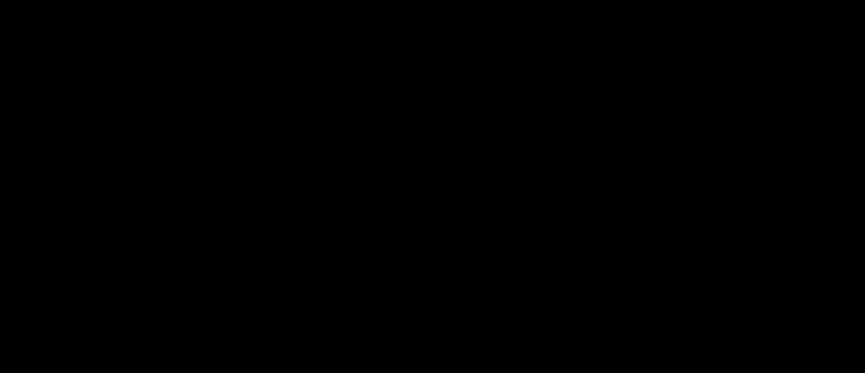
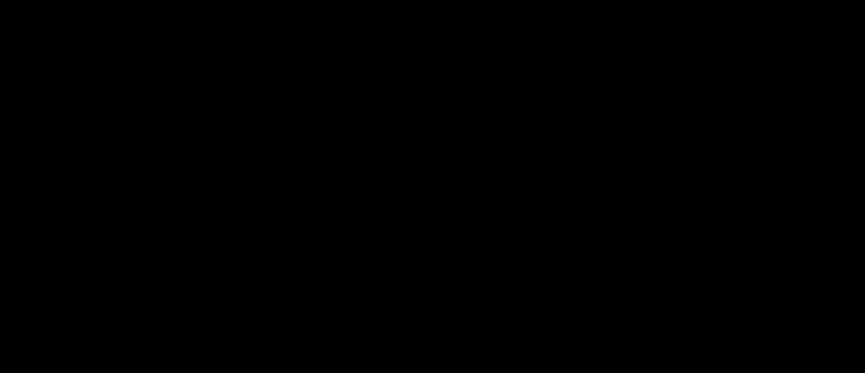

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import arff
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, roc_auc_score

file_path = 'data/diabetic+retinopathy+debrecen/messidor_features.arff'
data, meta = arff.loadarff(file_path)
df = pd.DataFrame(data)
print(df)

# X = Tüm sütunlar, son sütun hariç
X = df.iloc[:, :-1]
# y = Sadece son sütun (Class)
y = df.iloc[:, -1].to_frame()

# 3. y'deki byte stringleri (b'0', b'1') temiz sayıya (0, 1) çevirme
# (Bu, veriyi modelin anlayacağı sayısal formata getirir.)
y['Class'] = y['Class'].str.decode('utf-8').astype(int)

print("Yüklemeler ve instance ayarlamarı tamamdır.")

        0    1     2     3     4     5     6     7          8          9  \
0     1.0  1.0  22.0  22.0  22.0  19.0  18.0  14.0  49.895756  17.775994   
1     1.0  1.0  24.0  24.0  22.0  18.0  16.0  13.0  57.709936  23.799994   
2     1.0  1.0  62.0  60.0  59.0  54.0  47.0  33.0  55.831441  27.993933   
3     1.0  1.0  55.0  53.0  53.0  50.0  43.0  31.0  40.467228  18.445954   
4     1.0  1.0  44.0  44.0  44.0  41.0  39.0  27.0  18.026254   8.570709   
...   ...  ...   ...   ...   ...   ...   ...   ...        ...        ...   
1146  1.0  1.0  34.0  34.0  34.0  33.0  31.0  24.0   6.071765   0.937472   
1147  1.0  1.0  49.0  49.0  49.0  49.0  45.0  37.0  63.197145  27.377668   
1148  1.0  0.0  49.0  48.0  48.0  45.0  43.0  33.0  30.461898  13.966980   
1149  1.0  1.0  39.0  36.0  29.0  23.0  13.0   7.0  40.525739  12.604947   
1150  1.0  1.0   7.0   7.0   7.0   7.0   7.0   5.0  69.423565   7.031843   

             10        11        12        13        14        15        16  \
0      5

In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1151 entries, 0 to 1150
Data columns (total 19 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       1151 non-null   float64
 1   1       1151 non-null   float64
 2   2       1151 non-null   float64
 3   3       1151 non-null   float64
 4   4       1151 non-null   float64
 5   5       1151 non-null   float64
 6   6       1151 non-null   float64
 7   7       1151 non-null   float64
 8   8       1151 non-null   float64
 9   9       1151 non-null   float64
 10  10      1151 non-null   float64
 11  11      1151 non-null   float64
 12  12      1151 non-null   float64
 13  13      1151 non-null   float64
 14  14      1151 non-null   float64
 15  15      1151 non-null   float64
 16  16      1151 non-null   float64
 17  17      1151 non-null   float64
 18  18      1151 non-null   float64
dtypes: float64(19)
memory usage: 171.0 KB


In [10]:
y.value_counts()

Class
1        611
0        540
Name: count, dtype: int64